# 01. Exploration and pair-level dataset

Speed Dating Experiment, Columbia 2002 to 2004. The client wants to know which pairs are worth
recommending, so the target is `match`: both people said yes after their four-minute date.

Three jobs: fix the unit of observation, decide which variables we may use, and save one row per
pair. Run it from the repository root.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from pathlib import Path

if not Path("data").is_dir():
    os.chdir("..")   # works whether Jupyter started at the repo root or inside notebooks/

pd.set_option("display.max_columns", 60)

# The file has a few Mac Roman characters in the free-text fields.
df = pd.read_csv("data/raw/speed_dating.csv", encoding="mac_roman")

# Three numeric columns arrive as text, with a thousands separator ("69,487.00").
for c in ["income", "mn_sat", "tuition"]:
    df[c] = pd.to_numeric(df[c].str.replace(",", "", regex=False), errors="coerce")

df.shape

(8378, 195)

In [2]:
## celia the greatest

## 1. One row is one person's view of one date

551 participants took part in 21 speed dating sessions ("waves"). Everyone met every participant of
the opposite sex in their wave, and each of those dates produced **two** rows: one filled in by her,
one filled in by him. `iid` is the person who filled the row, `pid` the partner.

In [3]:
print("rows:", len(df), " participants:", df.iid.nunique(), " waves:", df.wave.nunique())
print("rows with no partner id:", df.pid.isna().sum())

d = df.dropna(subset=["pid"]).copy()
d["pid"] = d["pid"].astype(int)
d["pair"] = [tuple(sorted(p)) for p in zip(d.iid, d.pid)]

print("unique pairs:", d.pair.nunique())
print("rows per pair:", sorted(d.pair.value_counts().unique()))

rows: 8378  participants: 551  waves: 21
rows with no partner id: 10
unique pairs: 4184
rows per pair: [np.int64(2)]


In [4]:
# The two rows of a pair must agree on the target, and every pair must be a woman and a man.
print("pairs where match differs between the two rows:", (d.groupby("pair").match.nunique() > 1).sum())
print("pairs that are not woman-man:", (d.groupby("pair").gender.nunique() != 2).sum())

d[d.pair == d.pair.iloc[0]][["iid", "pid", "gender", "age", "race", "dec", "dec_o", "match"]]

pairs where match differs between the two rows: 0
pairs that are not woman-man: 0


,iid,pid,gender,age,race,dec,dec_o,match
0,1,11,0,21.0,4.0,1,0,0
100,11,1,1,27.0,2.0,0,1,0


In [5]:
# The pairs are not independent: the same people come back in many of them.
dates_per_person = df.groupby("iid").size()
print("dates per participant:", int(dates_per_person.median()), "median,",
      dates_per_person.min(), "to", dates_per_person.max())
print("participants per wave:", int(df.groupby("wave").iid.nunique().median()), "median")

dates per participant: 16 median, 5 to 22
participants per wave: 24 median


Every participant appears in about sixteen pairs, so even a split that keeps whole waves together
leaves strong dependence inside each side. Notebook 05 measures that.

`match` is `dec` and `dec_o` both equal to 1, seen from each side, so the two rows of a date carry the
same outcome. Keeping both would duplicate every observation and let the same date sit on both sides
of a split. **We build one row per pair.**

The next cells check that: the two rows of a pair always agree on the target, and every pair is one
woman and one man.

## 2. Which variables are we allowed to use?

The client ranks pairs **before** the date, so anything recorded during or after it is unusable, however
well it predicts. Three groups go:

- **during the date**: the scorecard (`dec`, `attr`, `sinc`, `intel`, `fun`, `amb`, `shar`, `like`,
  `prob`, `met`) and the same fields seen by the partner, suffix `_o`. `dec` and `dec_o` *are* the target.
- **after the date**: the follow-up surveys, suffixes `_s`, `_2`, `_3`, plus `match_es`, `length`,
  `you_call`, `them_cal`.
- **the partner echo**: `age_o`, `race_o`, `pf_o_*` repeat the partner's own answers, which we get from
  their own columns once both people are on the same row.

In [6]:
during = ["dec", "attr", "sinc", "intel", "fun", "amb", "shar", "like", "prob", "met"]
during = during + [c + "_o" for c in during]

after = [c for c in df.columns if c.endswith(("_s", "_2", "_3"))]
after += ["match_es", "length", "you_call", "them_cal"]

echo = ["age_o", "race_o"] + [c for c in df.columns if c.startswith("pf_o_")]

# These describe the date itself and are identical on both rows of a pair.
pair_level = ["int_corr", "samerace"]

# Identifiers and event logistics: not profile information, handled separately when we build the pairs.
design = ["iid", "id", "idg", "pid", "partner", "wave", "round", "position", "positin1",
          "order", "condtn", "gender"]

usable = [c for c in df.columns
          if c not in during + after + echo + design + pair_level + ["match"]]

for name, cols in [("during the date", during), ("after the date", after),
                   ("partner echo", echo), ("design / ids", design),
                   ("pair level", pair_level), ("usable", usable)]:
    print(f"{name:20s} {len(cols):3d}")

during the date       20
after the date        88
partner echo           8
design / ids          12
pair level             2
usable                64


## 3. What the variables mean, and how they are coded

Almost every profile column is a number, but not in the same sense. Mixing the families up is the
easiest way to build a model that looks fine and means nothing.

| Family | Columns | What it means for the modelling |
|---|---|---|
| Labels stored as numbers | `field_cd` (18 fields), `career_c` (17 careers), `goal` (6 reasons for coming), `race` (6 groups) | no order at all, so one-hot encoding |
| Ratings from 1 to 10 | the 17 activity interests, `imprace`, `imprelig`, `exphappy` | genuine ordinal scales, usable as numbers |
| Frequencies, coded backwards | `date`, `go_out` | 1 means *several times a week*, 7 *almost never* |
| Point allocations | the `1_1`, `2_1`, `4_1` blocks | six columns summing to 100: shares, not levels |

In [7]:
people = df.drop_duplicates("iid")  # the sign-up survey: one row per participant, not per date

RACE = {1: "Black", 2: "White", 3: "Latino", 4: "Asian", 5: "Native American", 6: "Other"}
GOAL = {1: "fun night out", 2: "meet new people", 3: "get a date",
        4: "serious relationship", 5: "to say I did it", 6: "other"}
FREQ = {1: "several times a week", 2: "twice a week", 3: "once a week", 4: "twice a month",
        5: "once a month", 6: "several times a year", 7: "almost never"}

print(people.goal.map(GOAL).value_counts())

goal
fun night out           228
meet new people         189
get a date               40
to say I did it          35
other                    30
serious relationship     22
Name: count, dtype: int64


In [8]:
# `date` and `go_out` run from often to never, which is worth seeing once before trusting a sign.
pd.DataFrame({"go_out": people.go_out.map(FREQ).value_counts(),
              "date": people.date.map(FREQ).value_counts()}).reindex(FREQ.values())

,go_out,date
several times a week,177,7
twice a week,191,22
once a week,127,54
twice a month,29,131
once a month,12,99
several times a year,6,136
almost never,2,94


Most participants go out at least once a week, and both columns are concentrated on the "often" end.
Nothing to repair, but the direction has to be written down somewhere, or every interpretation of
these two variables comes out backwards.

In [9]:
ACTIVITIES = ["sports", "tvsports", "exercise", "dining", "museums", "art", "hiking", "gaming",
              "clubbing", "reading", "tv", "theater", "movies", "concerts", "music", "shopping", "yoga"]
SCALES = ACTIVITIES + ["imprace", "imprelig", "exphappy"]

# These are all supposed to run from 1 to 10.
off = {c: sorted(int(v) for v in people.loc[~people[c].between(1, 10) & people[c].notna(), c].unique())
       for c in SCALES}
print({c: v for c, v in off.items() if v})

{'museums': [0], 'art': [0], 'hiking': [0], 'gaming': [0, 14], 'clubbing': [0], 'reading': [13], 'theater': [0], 'movies': [0], 'concerts': [0], 'yoga': [0], 'imprace': [0]}


Fifteen participants are outside the scale: a few zeros, and answers of 13 and 14 to questions that
stop at 10. These look like typing mistakes rather than another scale, so we bring them back to the
nearest valid value instead of dropping the rows.

In [10]:
df[SCALES] = df[SCALES].clip(1, 10)
d[SCALES] = d[SCALES].clip(1, 10)  # `d` is the copy the pairs are built from

people = df.drop_duplicates("iid")  # refresh the participant view after the fix
print("values still outside 1-10:", int(((df[SCALES] < 1) | (df[SCALES] > 10)).sum().sum()))

values still outside 1-10: 0


## 4. Missing values

Everything is self-reported, and the optional questions were answered by half the participants.

expnum      0.785
mn_sat      0.626
tuition     0.572
income      0.489
sinc5_1     0.414
attr5_1     0.414
amb5_1      0.414
intel5_1    0.414
fun5_1      0.414
undergra    0.413
shar4_1     0.228
amb4_1      0.225
attr4_1     0.225
sinc4_1     0.225
intel4_1    0.225
dtype: float64

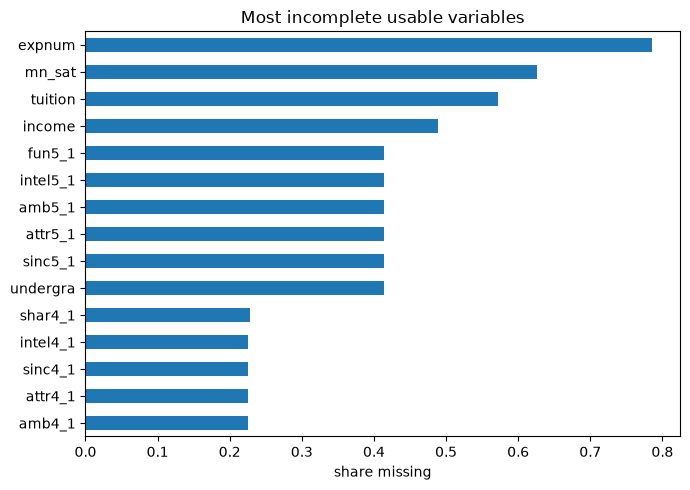

In [11]:
miss = df[usable].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
miss.head(15).sort_values().plot.barh(ax=ax)
ax.set_xlabel("share missing")
ax.set_title("Most incomplete usable variables")
plt.tight_layout()

miss.head(15).round(3)

In [12]:
# The codebook is explicit: income is missing when the person is from abroad or gave no zip code.
pd.DataFrame({"income missing": people.income.isna().groupby(people.race.map(RACE)).mean().round(3),
              "participants": people.race.map(RACE).value_counts()})

,income missing,participants
race,,
Asian,0.603,136
Black,0.308,26
Latino,0.619,42
Other,0.514,37
White,0.424,304


The missingness is not random. 62% of Latino and 60% of Asian participants have no income, against
31% of Black participants, so "income is missing" is itself a signal about origin. Imputing it
silently would be the wrong move, and 06 comes back to it.

`expnum`, `mn_sat`, `tuition` and `undergra` are the other optional questions. We keep everything for
now and decide in 02. `zipcode` stays text: it is a code, not a quantity.

## 5. The target

A match is rare: roughly one date out of six. That imbalance drives everything later (we will look at
ranking metrics rather than accuracy, and the cost matrix for the economic evaluation).

match rate: 0.1647


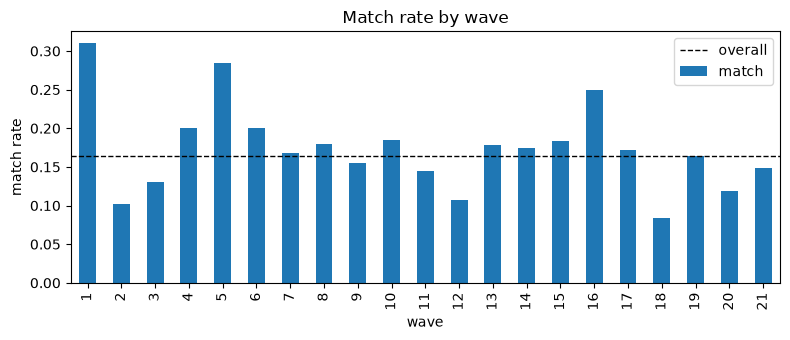

In [13]:
print("match rate:", df.match.mean().round(4))

rate_by_wave = df.groupby("wave").match.mean()

fig, ax = plt.subplots(figsize=(8, 3.5))
rate_by_wave.plot.bar(ax=ax)
ax.axhline(df.match.mean(), color="black", linestyle="--", linewidth=1, label="overall")
ax.set_ylabel("match rate")
ax.set_title("Match rate by wave")
ax.legend()
plt.tight_layout()

In [14]:
# `dec` is a during-the-date variable, unusable as a feature, but it explains where the base rate
# comes from: a match needs two yes.
yes = df.groupby("gender").dec.mean()

print("women say yes:", yes[0].round(3))
print("men say yes:  ", yes[1].round(3))
print("if both decisions were independent:", (yes[0] * yes[1]).round(3))
print("observed match rate:", df.match.mean().round(3))

women say yes: 0.365
men say yes:   0.474
if both decisions were independent: 0.173
observed match rate: 0.165


Women say yes to 37% of their dates, men to 47%. The bottleneck of the matching engine is her
decision, and that is worth telling the client directly.

The match rate also runs from under 10% to over 30% depending on the wave. Waves differ in size, in
the rules given to participants and in the population, which is the first reason to split by wave.

The match rate runs from under 10% to over 30% depending on the evening. That is one reason to be
careful with the waves; the decisive one comes in section 6.

## 6. How the experiment was run

The waves are not just a way of organising evenings. The protocol changed from one to the next: wave 5
was undergraduates only, waves 6 to 9 used the 1 to 10 preference scale, waves 13 and 14 had a
different host, waves 18 to 21 asked participants to bring a book, and one wave was given a quota. Two
of those changes show up in the target.

In [15]:
# condtn is fixed for a whole wave: 1 = limited choice, 2 = extensive choice.
wave_size = df.groupby("wave").iid.nunique()
wave_condtn = df.groupby("wave").condtn.first()

print(df.groupby("condtn").agg(waves=("wave", "nunique"), dates=("match", "size"),
                               yes_rate=("dec", "mean"), match_rate=("match", "mean")).round(3))
print()
print("participants per wave:")
print(wave_size.groupby(wave_condtn).agg(["min", "max"]))
print("correlation between wave size and yes rate:",
      round(wave_size.corr(df.groupby("wave").dec.mean()), 2))

        waves  dates  yes_rate  match_rate
condtn                                    
1          10   1434     0.460       0.202
2          11   6944     0.412       0.157

participants per wave:
        min  max
condtn          
1        10   20
2        24   44
correlation between wave size and yes rate: -0.42


A small evening and a large one are two different games. With few partners people say yes to 46% of
them, with many only 41%, and the match rate falls from 20.2% to 15.7%. More choice makes people more
selective.

In [16]:
print("median age, wave 5 vs the rest:",
      people[people.wave == 5].age.median(), "vs", people[people.wave != 5].age.median())

# One wave was allowed to say yes to at most half of its dates.
highest = df.groupby(["wave", "iid"]).dec.mean().groupby("wave").max()
print("waves where nobody said yes more than half the time:", highest[highest <= 0.5].index.tolist())
print("highest individual yes rate elsewhere:", highest[highest > 0.5].min())

median age, wave 5 vs the rest: 21.0 vs 26.0
waves where nobody said yes more than half the time: [12]
highest individual yes rate elsewhere: 0.8


Wave 5 is the undergraduate evening and wave 12 is the one with the quota: nobody there said yes more
than half the time, when every other wave has someone above 80%. Its 196 dates have an artificially low
match rate. We keep them, because dropping a wave over its protocol is a choice we would then have to
defend, and 5% of the data will not move the conclusions.

In [17]:
# Could we split on anything finer than a wave? Link two people if they dated, then count the
# pieces of that graph that have no link between them.
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

ids = sorted(set(d.iid) | set(d.pid))
place = {v: i for i, v in enumerate(ids)}
links = coo_matrix((np.ones(len(d)), (d.iid.map(place), d.pid.map(place))),
                   shape=(len(ids), len(ids)))

print("groups of people with no date between them:", connected_components(links, directed=False)[0])
print("waves:", d.wave.nunique())

groups of people with no date between them: 21
waves: 21


**Twenty-one groups for twenty-one waves.** Everyone meets everyone of the opposite sex on their
evening, so a wave is exactly one connected block of people, and there is no finer cut that keeps an
individual on one side only.

This is the argument for the split, and it is worth stating precisely because it is easy to
misread. The wave is a **grouping key, never a feature**: notebook 02 removes it, and removes anything
constant within a wave, so the model never sees which evening a pair came from. What the wave decides
is only who lands in which fold. The choice is not "split by wave or at random", it is "split by wave,
or accept the same person in the training set and the test set".

## 7. Ethnicity, our protected attribute

Two things to check before modelling: how unbalanced the groups are, and whether the target is
already unequal.

In [18]:
race = df.race.map(RACE)  # RACE was defined with the other code maps
counts = race.value_counts()
print(counts)
print("\nmissing race:", df.race.isna().sum(), "rows")
print("\nshare of the sample:")
print((counts / counts.sum()).round(3))

race
White     4727
Asian     1982
Latino     664
Other      522
Black      420
Name: count, dtype: int64

missing race: 63 rows

share of the sample:
race
White     0.568
Asian     0.238
Latino    0.080
Other     0.063
Black     0.051
Name: count, dtype: float64


In [19]:
# Match rate by ethnicity. Every date is counted from both sides, so this is the rate
# for the dates involving someone of that group.
df.groupby(race).match.agg(["mean", "size"]).round(3)

,mean,size
race,,
Asian,0.135,1982
Black,0.202,420
Latino,0.185,664
Other,0.197,522
White,0.167,4727


In [20]:
print(df.groupby("samerace").match.agg(["mean", "size"]).round(3))
print("\nmatch rate when both are White:", df[(df.race == 2) & (df.race_o == 2)].match.mean().round(3))

           mean  size
samerace             
0         0.161  5062
1         0.171  3316

match rate when both are White: 0.175


### How much do people care about it themselves?

At sign-up everyone rated *"how important is it that the person you date is of the same racial or
ethnic background?"* from 1 to 10 (`imprace`). It is a pre-date answer, so we may use it.

In [21]:
print(people.groupby(people.race.map(RACE)).imprace.agg(["mean", "size"]).round(2))
print("\nmean by gender:", people.groupby("gender").imprace.mean().round(2).to_dict())
print("missing:", people.imprace.isna().sum(), "of", len(people), "participants")

        mean  size
race              
Asian   3.38   136
Black   3.46    26
Latino  2.67    42
Other   2.89    37
White   4.17   304

mean by gender: {0: 4.12, 1: 3.36}
missing: 7 of 551 participants


In [22]:
level = pd.cut(df.imprace, [0, 2, 5, 10], labels=["1-2 (low)", "3-5", "6-10 (high)"])
df.groupby(level, observed=True).match.agg(["mean", "size"]).round(3)

,mean,size
imprace,,
1-2 (low),0.180,3760
3-5,0.166,2150
6-10 (high),0.138,2389


**What it says.** White participants care most, 4.2 on average, Latino participants least, 2.7, and
women more than men, 4.1 against 3.4. People who care match less often: 18.0% at the bottom of the
scale against 13.8% at the top. Same-background dates match about one point more often.

The groups are very unbalanced: White participants are 56% of the sample, Black participants 5%, and
nobody selected Native American.

**Conclusion.** `imprace` is the variable to watch. It is legitimate to use, and it lets a model
reproduce a preference for same-background pairs **without ever reading `race`**. Dropping the
protected attribute will not be enough, which 06 confirms. And fairness metrics on the smallest
groups will need intervals, not point estimates.

## 8. The preference questions need a fix

At sign-up each participant spread 100 points over six qualities they look for (`attr1_1` to
`shar1_1`), what they think the opposite sex looks for (`2_1`), and what they think their peers look
for (`4_1`). The codebook warns that waves 6 to 9 used a 1 to 10 rating instead. Which blocks are
actually affected?

In [23]:
QUALITIES = ["attr", "sinc", "intel", "fun", "amb", "shar"]

sums = {}  # `people` was built above: these questions are also answered once per participant
for block in ["1_1", "2_1", "4_1"]:
    cols = [q + block for q in QUALITIES]
    sums[block] = people[cols].sum(axis=1).groupby(people.wave).median()

pd.DataFrame(sums)

,1_1,2_1,4_1
wave,,,
1,100.0,100.0,0.0
2,100.0,100.0,0.0
3,100.0,100.0,0.0
4,100.0,100.0,0.0
5,100.0,100.0,0.0
6,100.0,100.0,43.5
7,100.0,100.0,44.5
8,100.0,100.0,44.0
9,100.0,100.0,45.0


Only the `4_1` block is affected: it was not asked at all in waves 1 to 5, uses the 1-10 scale in
waves 6 to 9, and the 100 points elsewhere. The `1_1` and `2_1` blocks are already on the 100-point
scale everywhere, contrary to what the codebook suggests. We rescale `4_1` for waves 6-9 so that the
column means the same thing in every wave.

In [24]:
pref4 = [q + "4_1" for q in QUALITIES]
rescale = d.wave.between(6, 9)

totals = d.loc[rescale, pref4].sum(axis=1)
d.loc[rescale, pref4] = d.loc[rescale, pref4].div(totals, axis=0) * 100

# the block now sums to 100 in every wave that asked the question
d[pref4].sum(axis=1).groupby(d.wave).median().round(1)

wave
1       0.0
2       0.0
3       0.0
4       0.0
5       0.0
6     100.0
7     100.0
8     100.0
9     100.0
10    100.0
11    100.0
12    100.0
13    100.0
14    100.0
15    100.0
16    100.0
17    100.0
18    100.0
19    100.0
20    100.0
21    100.0
dtype: float64

## 9. One row per pair

The woman's profile and the man's side by side, prefixes `w_` and `m_`. What describes the pair or the
evening (`wave`, `samerace`, `int_corr`, `position`) is identical on both rows and kept once; `order`
and `round` differ, so they stay on each side. The ten rows with no partner id are lost here.

In [25]:
per_person = usable + ["order", "round"]

women = d[d.gender == 0].set_index("pair")
men = d[d.gender == 1].set_index("pair")

pairs = pd.concat([
    women[per_person].add_prefix("w_"),
    men[per_person].add_prefix("m_"),
    # Each side's own yes/no. These are outcomes, not features: notebook 03 predicts them
    # separately and multiplies, since a match is simply both of them saying yes.
    women[["dec"]].add_prefix("w_"),
    men[["dec"]].add_prefix("m_"),
    women[["wave", "position", "samerace", "int_corr", "match"]],
], axis=1).reset_index()

print(pairs.shape)
print("match rate:", pairs.match.mean().round(4), "(was", df.match.mean().round(4), "on the raw rows)")
pairs.head(3)

(4184, 140)
match rate: 0.1649 (was 0.1647 on the raw rows)


,pair,w_age,w_field,w_field_cd,w_undergra,w_mn_sat,w_tuition,w_race,w_imprace,w_imprelig,w_from,w_zipcode,w_income,w_goal,w_date,w_go_out,w_career,w_career_c,w_sports,w_tvsports,w_exercise,w_dining,w_museums,w_art,w_hiking,w_gaming,w_clubbing,w_reading,w_tv,w_theater,...,m_sinc4_1,m_intel4_1,m_fun4_1,m_amb4_1,m_shar4_1,m_attr2_1,m_sinc2_1,m_intel2_1,m_fun2_1,m_amb2_1,m_shar2_1,m_attr3_1,m_sinc3_1,m_fun3_1,m_intel3_1,m_amb3_1,m_attr5_1,m_sinc5_1,m_intel5_1,m_fun5_1,m_amb5_1,m_order,m_round,w_dec,m_dec,wave,position,samerace,int_corr,match
0,"(1, 11)",21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521",69487.0,2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,...,NaN,NaN,NaN,NaN,NaN,25.0,5.0,20.0,20.0,25.0,5.0,8.0,9.0,7.0,8.0,5.0,NaN,NaN,NaN,NaN,NaN,4,10,1,0,1,7,0,0.14,0
1,"(1, 12)",21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521",69487.0,2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,...,NaN,NaN,NaN,NaN,NaN,25.0,15.0,25.0,20.0,15.0,0.0,9.0,9.0,9.0,10.0,9.0,NaN,NaN,NaN,NaN,NaN,3,10,1,0,1,7,0,0.54,0
2,"(1, 13)",21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521",69487.0,2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,...,NaN,NaN,NaN,NaN,NaN,20.0,16.0,16.0,18.0,16.0,14.0,4.0,7.0,8.0,8.0,3.0,NaN,NaN,NaN,NaN,NaN,10,10,1,1,1,7,1,0.16,1


In [26]:
# The same date must not end up on both sides of a split, so we check the pair key is unique
# and that every pair belongs to exactly one wave.
assert pairs.pair.is_unique
assert pairs.wave.notna().all()
print("pairs:", len(pairs), " waves:", pairs.wave.nunique(), " columns:", pairs.shape[1])

pairs: 4184  waves: 21  columns: 140


## 10. Save

In [27]:
Path("data/processed").mkdir(parents=True, exist_ok=True)
pairs.to_csv("data/processed/pairs.csv", index=False)
print("saved", pairs.shape, "to data/processed/pairs.csv")

saved (4184, 140) to data/processed/pairs.csv


## What we take to the next notebook

- One row per pair, 4,184 dates, target `match` at 16.5%, plus `w_dec` and `m_dec`: she says yes to
  37% of her dates, he to 47%.
- Pre-date information only.
- **Split by `wave`**, because the 21 waves are the 21 connected blocks of people. The wave is a
  grouping key, not a feature.
- Ethnicity on both sides, `w_race`, `m_race`, `samerace`, as the protected attribute. The groups are
  small, so 06 will need intervals rather than point estimates.
- The strongest single relationship is worth six or seven points of match rate, so no one variable
  will carry the model.